例 13.4 养殖场养殖一类动物最多三年 (满三年的将送往市场卖掉), 按一岁、二岁和三岁将其分为三个年龄组. 一龄组是幼龄组, 二龄组和三龄组是有繁殖后代能力的成年组. 二龄组平均一年繁殖 4 个后代, 三龄组平均一年繁殖 3 个后代. 一龄组和二龄组动物能养殖成为下一年龄组动物的成活率分别为 0.5 和 0.25. 假设刚开始养殖时有三个年龄组的动物各 1000 头.

(1) 求五年内各年龄组动物数量.

(2) 分析种群的增长趋势.

(3) 如果每年平均向市场供应动物数 $\boldsymbol{C} = [s, s, s]^{\text{T}}$, 考虑每年都必须保持有每一年龄组的动物前提下, $s$ 应取多少为好.

解 (1) 由题设, 出生率向量 $\boldsymbol{\alpha} = [\alpha_1, \alpha_2, \alpha_3]^{\text{T}} = [0, 4, 3]^{\text{T}}$, 成活率向量 $\boldsymbol{\beta} = [\beta_1, \beta_2]^{\text{T}} = [0.5, 0.25]^{\text{T}}$, 记幼龄组、二龄组和三龄组动物第 $k$ 年的数量分别为 $x_1(k), x_2(k), x_3(k)$, $\boldsymbol{X}(k) = [x_1(k), x_2(k), x_3(k)]^{\text{T}}$, 根据出生率和成活率的题设条件, 建立如下差分方程模型
$$
\begin{cases}
x_1(k + 1) = 4x_2(k) + 3x_3(k), \\
x_2(k + 1) = 0.5x_1(k), \\
x_3(k + 1) = 0.25x_2(k).
\end{cases} \tag{13.8}
$$

写成矩阵形式

$$
\boldsymbol{X}(k + 1) = \tilde{\boldsymbol{L}}\boldsymbol{X}(k), \quad k = 0, 1, 2, \cdots, \tag{13.9}
$$

其中, $\tilde{\boldsymbol{L}} = \begin{bmatrix} 0 & 4 & 3 \\ 0.5 & 0 & 0 \\ 0 & 0.25 & 0 \end{bmatrix}$.

利用初值条件 $\boldsymbol{X}(0) = [1000, 1000, 1000]^{\text{T}}$, 求得五年内各年龄组动物数量如表 13.1 所示, 各年龄组动物数量的柱状图如图 13.1 所示.

**表 13.1 五年内各年龄组动物数量**

| 年份 | 幼龄组 | 二龄组 | 三龄组 |
| :---: | :---: | :---: | :---: |
| 1 | 7000 | 500 | 250 |
| 2 | 2750 | 3500 | 125 |
| 3 | 14375 | 1375 | 875 |
| 4 | 8125 | 7188 | 344 |
| 5 | 29781 | 4063 | 1797 |

本题中 Leslie 矩阵
$$
\tilde{\boldsymbol{L}} = \begin{bmatrix} 0 & 4 & 3 \\ 0.5 & 0 & 0 \\ 0 & 0.25 & 0 \end{bmatrix},
$$
$\tilde{\boldsymbol{L}}$ 的最大特征值为 $\lambda_1 = 1.5$, 对应的特征向量
$$
\boldsymbol{v}_1 = [0.9474, 0.3158, 0.0526]^{\text{T}}.
$$

计算得 $c = 3000$.

因而, 当 $k \to +\infty$ 时, 该种群的数量趋于无穷.

(3) 如果每年平均向市场出售动物 $\boldsymbol{C} = [s, s, s]^{\text{T}}$, 分析动物分布向量变化规律, 可知
$$
\boldsymbol{X}(k + 1) = \tilde{\boldsymbol{L}}\boldsymbol{X}(k) - \boldsymbol{C}, \quad k = 0, 1, 2, \cdots,
$$
因此有
$$
\boldsymbol{X}(k) = \tilde{\boldsymbol{L}}^k \boldsymbol{X}(0) - \left( \tilde{\boldsymbol{L}}^{(k - 1)} + \tilde{\boldsymbol{L}}^{(k - 2)} + \cdots + \tilde{\boldsymbol{L}} + \boldsymbol{I} \right) \boldsymbol{C}, \quad k = 1, 2, \cdots.
$$


考虑每年都必须保持有每一年龄组的动物, 应该有 $\boldsymbol{X}(k)$ 的所有元素都要大于零. 利用 Python 程序, 输入不同的参数 $s$, 观察数据计算结果, 由实验结果可知, 当取 $s = 100$ 时, 能保证每一年龄组动物数量不为零.


TX=
[[ 7000.     2750.    14375.     8125.    29781.25 ]
 [  500.     3500.     1375.     7187.5    4062.5  ]
 [  250.      125.      875.      343.75   1796.875]]


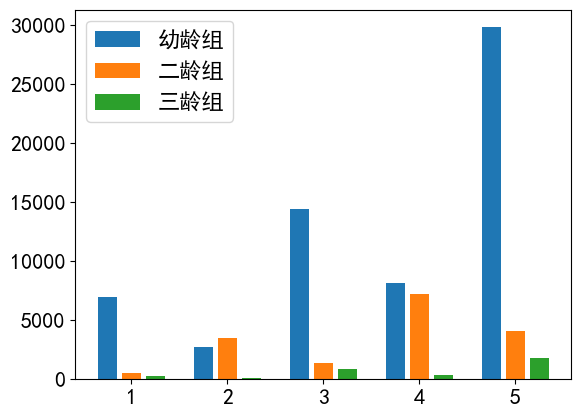

特征值=[ 1.5        -1.30901699 -0.19098301]
特征向量:
[[ 0.94736842 -0.93201073  0.225884  ]
 [ 0.31578947  0.35599642 -0.591372  ]
 [ 0.05263158 -0.06798927  0.774116  ]]
c={c}


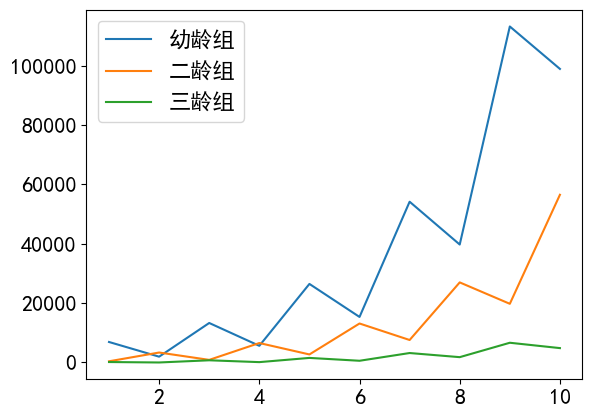

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = np.array([[0, 4, 3], [0.5, 0, 0], [0, 0.25, 0]])  # leslie矩阵(3, 3)
X = 1000 * np.ones((3, 1))  # 起始数量各1000头(3, 1 )   
TX = np.zeros((3, 5))  # 五年每年各年龄的数量
for i in range(5):
    X = L.dot(X)  # X_k+1 = L · X_k，(3, 1)
    TX[:, i] = X.flatten()  # flatten得到(3,)与左边对应
print(f"TX=\n{TX}")

plt.rcParams['font.size'] = 16
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

for i in range(3):
    plt.bar(np.arange(1, 6) - 0.25 + i / 4, TX[i], width=0.2)  # np.arange(1, 6)-0.25+i/4，每个组五年不同的横坐标
plt.legend(('幼龄组', '二龄组', '三龄组'))
plt.show()

val, vec = np.linalg.eig(L)
cv = np.linalg.inv(vec).dot(1000 * np.ones(3))  # P^(-1) · X(0), (3,)
c = abs(cv[0])
print(f"特征值={val}")
print(f"特征向量:\n{vec}")
print("c={c}")

s = int(input("输入s的值:"))
m = 10  # 10年种群数量变化
TY = []
Y = np.ones(3) * 1000  # (3,)
TY = np.zeros((m, 3))  # (10, 3)
for i in range(1, m+1):  # i:1~10
    Y = L.dot(Y) - s * np.ones(3)  # X_k+1 = L · X_k - C, (3,)
    TY[i-1, :] = Y.flatten()  # 每一行是一年的三个年龄段种群数量
plt.plot(np.arange(1, m+1), TY)
plt.legend(('幼龄组', '二龄组', '三龄组'))
plt.show()